
# Network Intrusion Detection Using Machine Learning
## Complete End-to-End Data Mining Project

This notebook includes:

- Data Loading
- Exploratory Data Analysis (EDA)
- Descriptive Statistics
- Inferential Statistics
- Data Visualization
- Data Preprocessing
- Feature Scaling
- Multiple ML Models
- Model Evaluation
- Model Comparison
- PyCaret AutoML Workflow

Dataset:
- NSL-KDD Dataset


In [ ]:
# Install Required Libraries
# Run this only once

# !pip install pandas numpy matplotlib seaborn scikit-learn scipy xgboost pycaret[full]


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC


import warnings
warnings.filterwarnings('ignore')

In [ ]:
!pip install xgboost

# Load Dataset:
    https://www.unb.ca/cic/datasets/nsl.html?utm_source=chatgpt.com
    https://www.kaggle.com/code/prthverm/cyber-security

NSL-KDD dataset files:

- KDDTrain+.txt
- KDDTest+.txt


In [2]:
# Column Names

columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes',
    'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
    'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
    'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
    'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate',
    'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate',
    'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate',
    'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
    'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'label', 'difficulty'
]


In [3]:
train_df = pd.read_csv('KDDTrain+.txt', names=columns)
test_df = pd.read_csv('KDDTest+.txt', names=columns)

df = pd.concat([train_df, test_df], ignore_index=True)

print("Number of rows and columns:")
print(df.shape)
print("\n")
print("First five rcords of the dataset")
df.head()

Number of rows and columns:
(148517, 43)


First five rcords of the dataset


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


# Initial Data Exploration

Concise feature descriptions suitable for adding into a Jupyter notebook documentation/markdown section for the KDD Cup 1999 Dataset / NSL-KDD intrusion detection dataset.

| Feature                       | Description                                                              |
| ----------------------------- | ------------------------------------------------------------------------ |
| `duration`                    | Length of the connection in seconds.                                     |
| `protocol_type`               | Type of protocol used (e.g., TCP, UDP, ICMP).                            |
| `service`                     | Network service on the destination (e.g., HTTP, FTP, Telnet).            |
| `flag`                        | Status flag of the connection indicating normal/error state.             |
| `src_bytes`                   | Number of data bytes sent from source to destination.                    |
| `dst_bytes`                   | Number of data bytes sent from destination to source.                    |
| `land`                        | 1 if source and destination IP/port are the same; otherwise 0.           |
| `wrong_fragment`              | Number of fragmented packets with incorrect offset.                      |
| `urgent`                      | Number of urgent packets in the connection.                              |
| `hot`                         | Number of suspicious or sensitive operations performed.                  |
| `num_failed_logins`           | Number of failed login attempts.                                         |
| `logged_in`                   | 1 if login was successful; otherwise 0.                                  |
| `num_compromised`             | Number of compromised conditions detected.                               |
| `root_shell`                  | 1 if root shell was obtained; otherwise 0.                               |
| `su_attempted`                | 1 if `su root` command was attempted; otherwise 0.                       |
| `num_root`                    | Number of root-level accesses or operations.                             |
| `num_file_creations`          | Number of file creation operations.                                      |
| `num_shells`                  | Number of shell prompts invoked.                                         |
| `num_access_files`            | Number of operations on access control files.                            |
| `num_outbound_cmds`           | Number of outbound commands in an FTP session.                           |
| `is_host_login`               | 1 if login belongs to host account list; otherwise 0.                    |
| `is_guest_login`              | 1 if login is a guest login; otherwise 0.                                |
| `count`                       | Number of connections to the same host in a given time window.           |
| `srv_count`                   | Number of connections to the same service in a given time window.        |
| `serror_rate`                 | Percentage of connections with SYN errors.                               |
| `srv_serror_rate`             | Percentage of same-service connections with SYN errors.                  |
| `rerror_rate`                 | Percentage of connections with REJ errors.                               |
| `srv_rerror_rate`             | Percentage of same-service connections with REJ errors.                  |
| `same_srv_rate`               | Percentage of connections to the same service.                           |
| `diff_srv_rate`               | Percentage of connections to different services.                         |
| `srv_diff_host_rate`          | Percentage of same-service connections to different hosts.               |
| `dst_host_count`              | Number of connections to the same destination host.                      |
| `dst_host_srv_count`          | Number of connections to the same service on destination host.           |
| `dst_host_same_srv_rate`      | Percentage of connections to same service on destination host.           |
| `dst_host_diff_srv_rate`      | Percentage of connections to different services on destination host.     |
| `dst_host_same_src_port_rate` | Percentage of connections from same source port.                         |
| `dst_host_srv_diff_host_rate` | Percentage of same-service connections to different hosts.               |
| `dst_host_serror_rate`        | Percentage of destination host connections with SYN errors.              |
| `dst_host_srv_serror_rate`    | Percentage of same-service destination host connections with SYN errors. |
| `dst_host_rerror_rate`        | Percentage of destination host connections with REJ errors.              |
| `dst_host_srv_rerror_rate`    | Percentage of same-service destination host connections with REJ errors. |
| `label`                       | Class label indicating normal traffic or attack type.                    |
| `difficulty`                  | Difficulty score assigned to classify the record correctly.              |


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148517 entries, 0 to 148516
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     148517 non-null  int64  
 1   protocol_type                148517 non-null  object 
 2   service                      148517 non-null  object 
 3   flag                         148517 non-null  object 
 4   src_bytes                    148517 non-null  int64  
 5   dst_bytes                    148517 non-null  int64  
 6   land                         148517 non-null  int64  
 7   wrong_fragment               148517 non-null  int64  
 8   urgent                       148517 non-null  int64  
 9   hot                          148517 non-null  int64  
 10  num_failed_logins            148517 non-null  int64  
 11  logged_in                    148517 non-null  int64  
 12  num_compromised              148517 non-null  int64  
 13 

In [5]:
# Missing Values
df.isnull().sum()

duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                  0
srv_diff_h

In [6]:
# Duplicate Records
df.duplicated().sum()

np.int64(610)

In [7]:
df.drop_duplicates(inplace=True)

#### Target Column:

In [8]:
df.label.unique()

array(['normal', 'neptune', 'warezclient', 'ipsweep', 'portsweep',
       'teardrop', 'nmap', 'satan', 'smurf', 'pod', 'back',
       'guess_passwd', 'ftp_write', 'multihop', 'rootkit',
       'buffer_overflow', 'imap', 'warezmaster', 'phf', 'land',
       'loadmodule', 'spy', 'perl', 'saint', 'mscan', 'apache2',
       'snmpgetattack', 'processtable', 'httptunnel', 'ps', 'snmpguess',
       'mailbomb', 'named', 'sendmail', 'xterm', 'worm', 'xlock',
       'xsnoop', 'sqlattack', 'udpstorm'], dtype=object)

In [9]:
df.label.value_counts()

label
normal             76967
neptune            45716
satan               4360
ipsweep             3643
smurf               3108
portsweep           3070
nmap                1566
back                1300
guess_passwd        1284
mscan                996
warezmaster          964
teardrop             901
warezclient          890
apache2              737
processtable         685
snmpguess            331
saint                319
mailbomb             293
pod                  221
snmpgetattack        178
httptunnel           133
buffer_overflow       50
multihop              25
rootkit               23
land                  22
named                 17
ps                    15
sendmail              14
xterm                 13
imap                  12
loadmodule            11
ftp_write             11
xlock                  9
phf                    6
perl                   5
xsnoop                 4
spy                    2
worm                   2
sqlattack              2
udpstorm           

# Target Variable Visualization

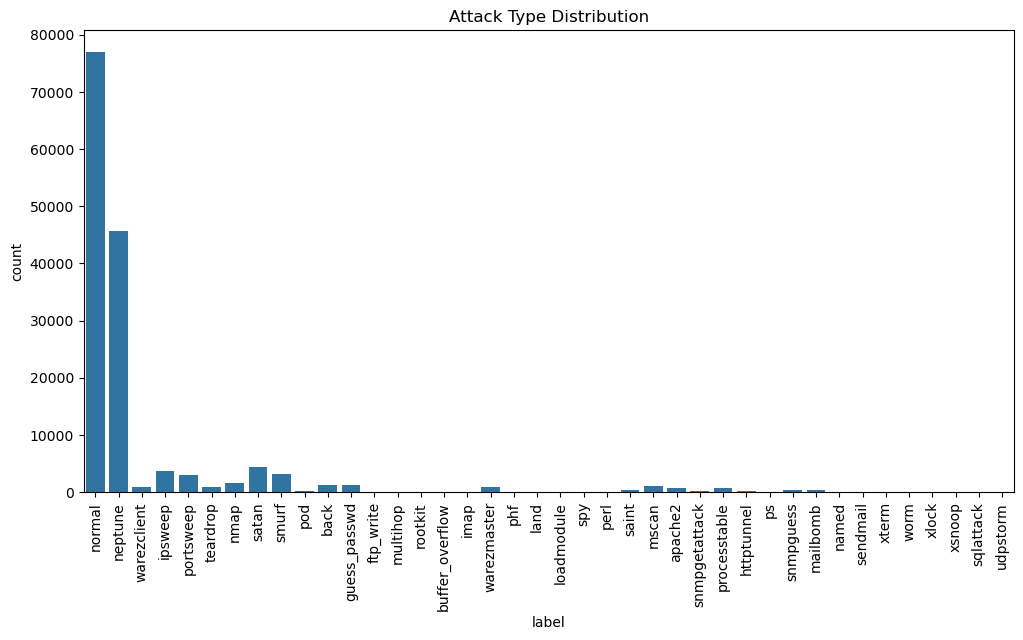

In [10]:
plt.figure(figsize=(12,6))
sns.countplot(x='label', data=df)
plt.xticks(rotation=90)
plt.title('Attack Type Distribution')
plt.show()

# Convert to Binary Classification

In [11]:
# Convert all attacks into single category

df['label'] = df['label'].apply( lambda x: 'normal' if x == 'normal' else 'attack')
df['label'].value_counts()


label
normal    76967
attack    70940
Name: count, dtype: int64

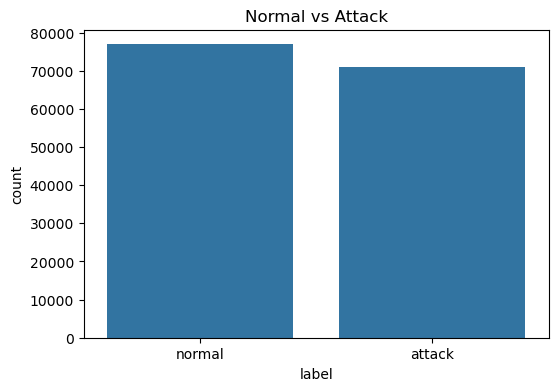

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.title('Normal vs Attack')
plt.show()


# Descriptive Statistics

In [13]:
df.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,difficulty
count,147907.000000,1.479070e+05,1.479070e+05,147907.000000,147907.000000,147907.000000,147907.000000,147907.000000,147907.000000,147907.000000,...,147907.000000,147907.000000,147907.000000,147907.000000,147907.000000,147907.000000,147907.000000,147907.000000,147907.000000,147907.000000
mean,277.920802,4.038680e+04,1.715835e+04,0.000196,0.020432,0.000203,0.189957,0.004341,0.404301,0.256012,...,119.388372,0.533852,0.084215,0.144211,0.030005,0.256797,0.251962,0.135927,0.136097,19.280670
std,2465.687803,5.420755e+06,3.711154e+06,0.014001,0.240040,0.019457,2.017189,0.072397,0.490758,22.277164,...,111.204986,0.447955,0.194118,0.306493,0.106307,0.428853,0.430083,0.322350,0.334929,2.742556
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,11.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.000000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,72.000000,0.590000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.000000,2.780000e+02,5.800000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,1.000000,0.070000,0.050000,0.010000,0.630000,0.550000,0.000000,0.000000,21.000000
max,57715.000000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,101.000000,5.000000,1.000000,7479.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


# Correlation Analysis

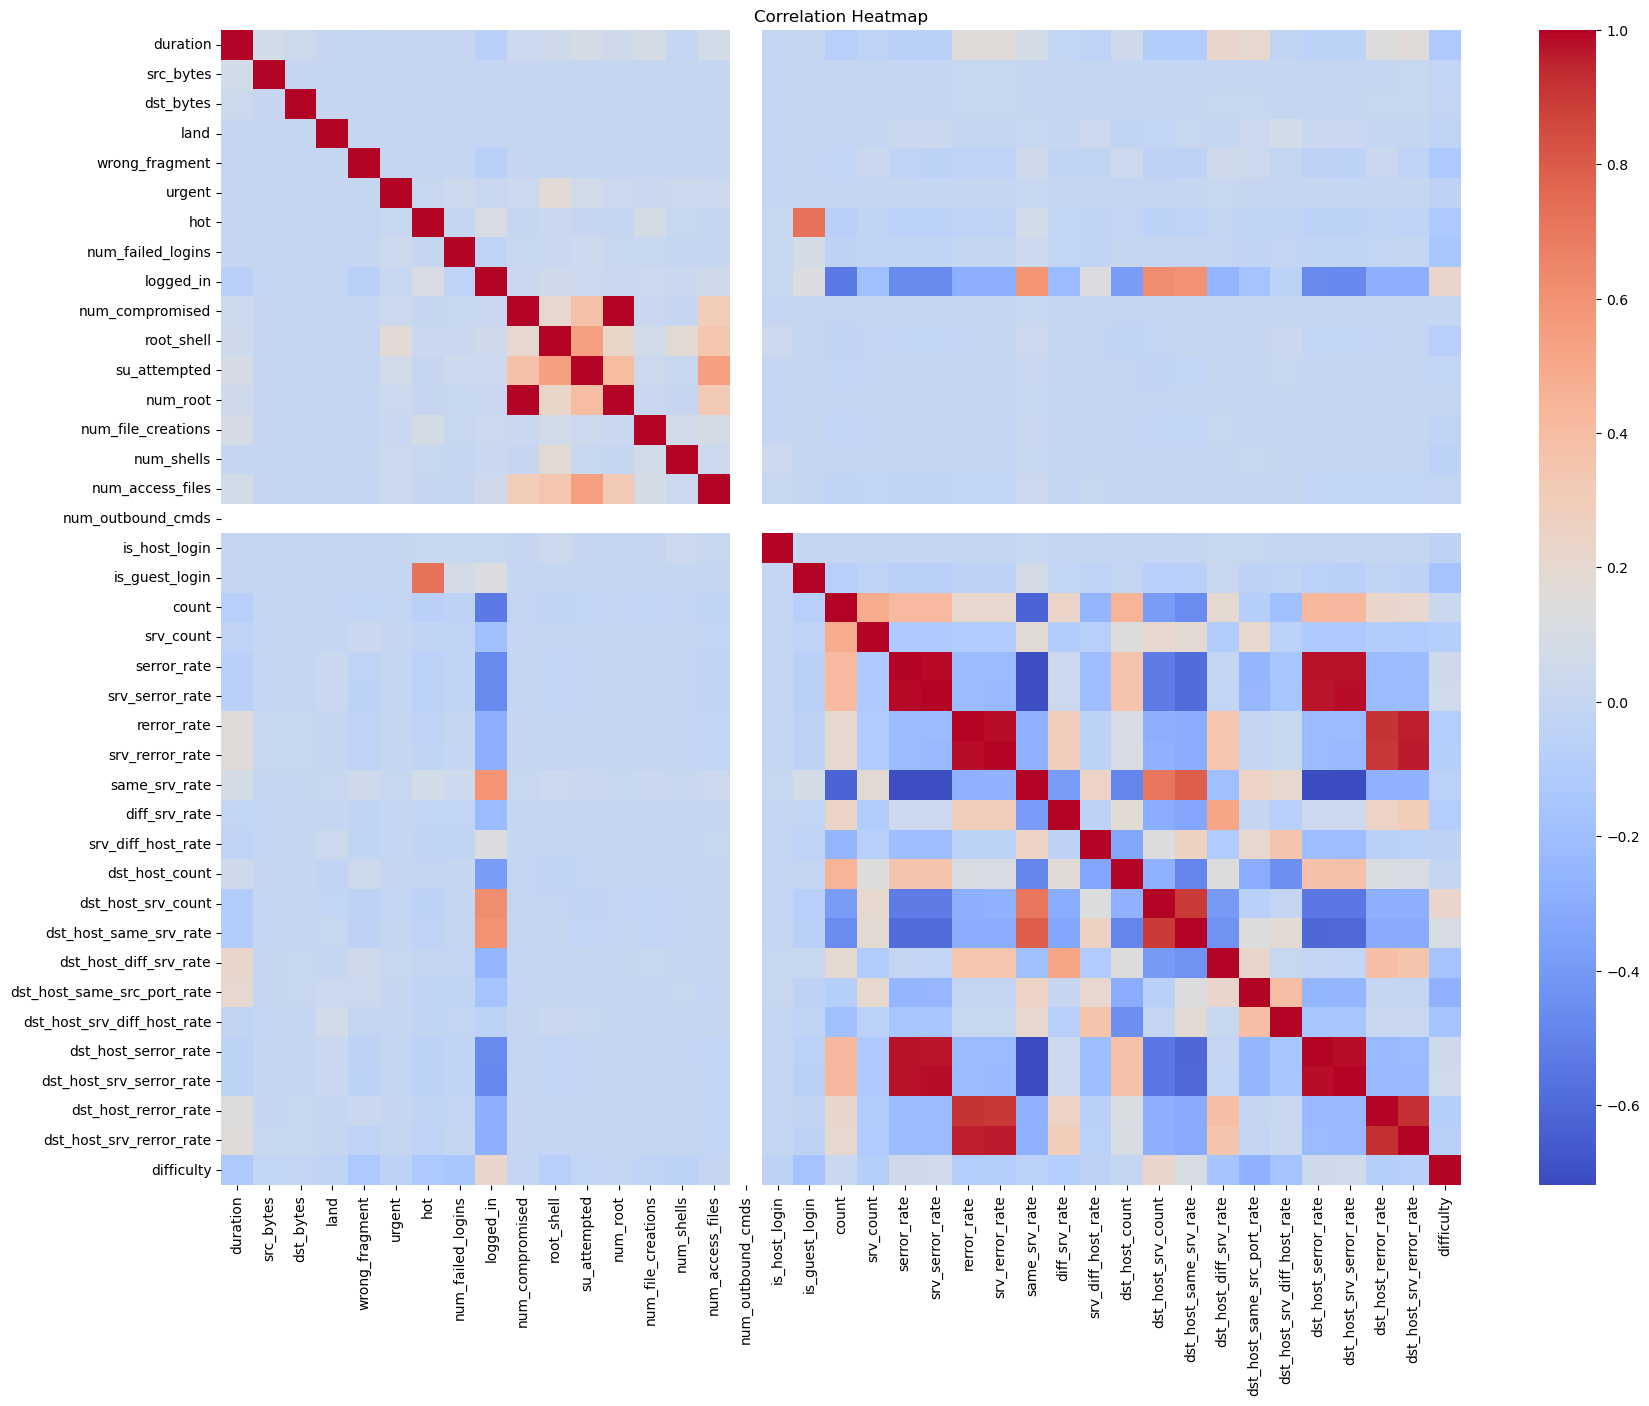

In [14]:
correlation_matrix = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(20,15))
sns.heatmap(correlation_matrix, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


# Univariate Analysis

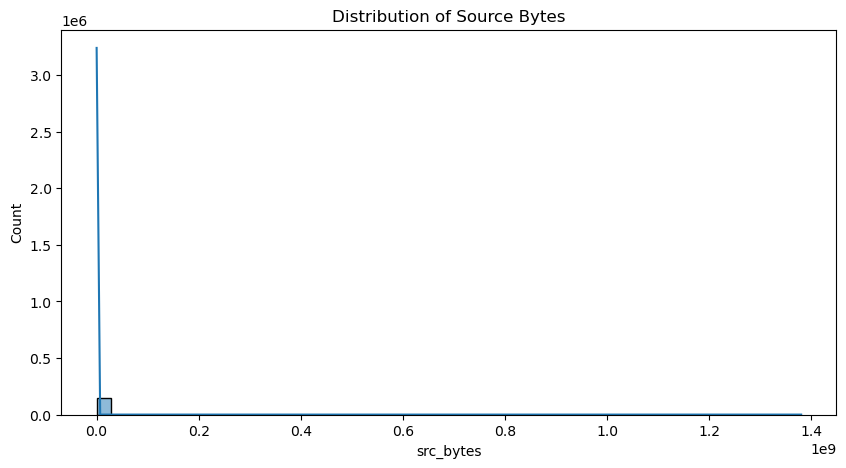

In [15]:
plt.figure(figsize=(10,5))
sns.histplot(df['src_bytes'], bins=50, kde=True)
plt.title('Distribution of Source Bytes')
plt.show()

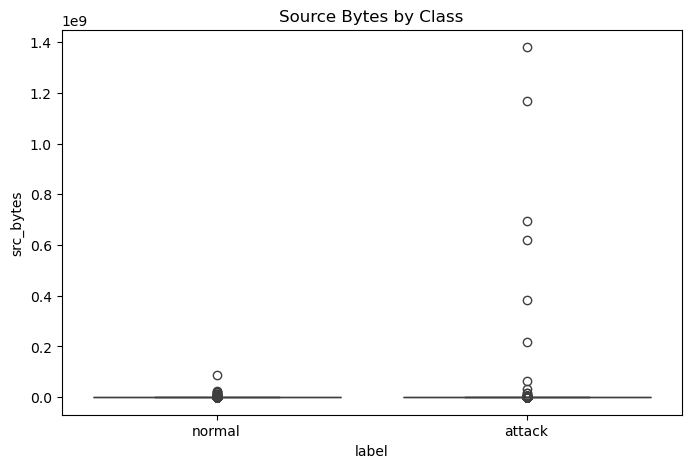

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(x='label', y='src_bytes', data=df)
plt.title('Source Bytes by Class')
plt.show()


# Bivariate Analysis

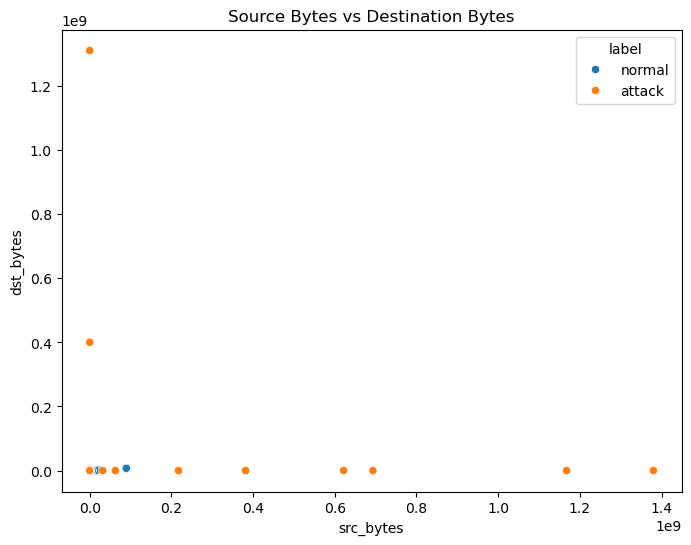

In [17]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='src_bytes',
    y='dst_bytes',
    hue='label',
    data=df
)
plt.title('Source Bytes vs Destination Bytes')
plt.show()


# Separating Taret and Predictors

In [18]:
# Encode categorical features

categorical_columns = ['protocol_type', 'service', 'flag']

encoder = LabelEncoder()

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

# Encode target variable
df['label'] = encoder.fit_transform(df['label'])

df.head()


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,1,20,9,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,1,20
1,0,2,44,9,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,1,15
2,0,1,49,5,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,0,19
3,0,1,24,9,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,1,21
4,0,1,24,9,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1,21


In [19]:
X = df.drop("label",axis=1)
y = df.label


In [20]:
y.value_counts()

label
1    76967
0    70940
Name: count, dtype: int64

# Splitting data into Train and Test sets

Class blancing
label
1    76967
0    76967
Name: count, dtype: int64


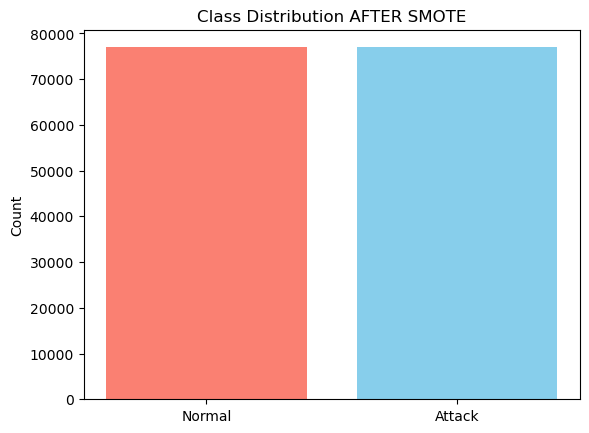

In [21]:
### Synthetic Data Generation Using SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE(sampling_strategy='minority', random_state=42)

X,y= smote.fit_resample(X,y)
print("Class blancing")
print(y.value_counts())
plt.bar(y.value_counts().index, y.value_counts().values, color=['skyblue','salmon'])
plt.xticks([0,1], ['Normal', 'Attack'])
plt.ylabel("Count")
plt.title("Class Distribution AFTER SMOTE")
plt.show()

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
                                    X, y, test_size=0.20, random_state=42)

In [23]:
y_train.value_counts()


label
0    61589
1    61558
Name: count, dtype: int64

In [24]:
y_test.value_counts()

label
1    15409
0    15378
Name: count, dtype: int64

In [25]:
cat_cols = X_train.select_dtypes('object')
num_cols = X_train.select_dtypes('number')

In [26]:
#  Numerical pipeline
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),   # handle missing numbers
    ("scaler", StandardScaler())
])

# Categorical pipeline
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),  # handle missing categories
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore",sparse_output=False))
])

In [27]:
preprocessor = ColumnTransformer(
                            transformers=[
                            ("num", num_pipeline, num_cols.columns),
                            ("cat", cat_pipeline, cat_cols.columns)
                            ])

In [28]:
model_pipeline = Pipeline(
    [
    ("preprocessor",  preprocessor),
    ("model", LogisticRegression())
    ]
)

model_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# Machine Learning Models

In [29]:

results = []

def evaluate_model(name, model):

    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    print(f"\n{name}")
    print("="*50)
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)

    print("\nClassification Report:")
    print(classification_report(y_test, predictions))

    cm = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

    return model



Logistic Regression
Accuracy: 0.8426283821093319
Precision: 0.8349822425164891
Recall: 0.8544357193847751
F1 Score: 0.8445969785418738

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.83      0.84     15378
           1       0.83      0.85      0.84     15409

    accuracy                           0.84     30787
   macro avg       0.84      0.84      0.84     30787
weighted avg       0.84      0.84      0.84     30787



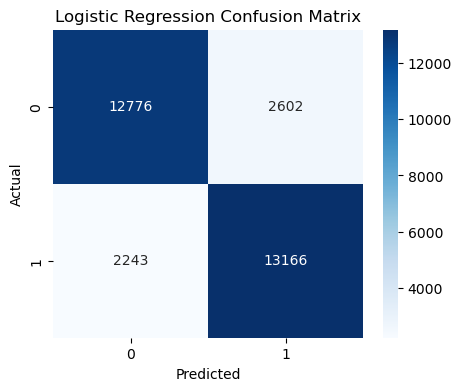

In [30]:
# Logistic Regression

lr_model = evaluate_model(
    'Logistic Regression',
    LogisticRegression()
)



Decision Tree
Accuracy: 0.9983109754116998
Precision: 0.9979894934820676
Recall: 0.9986371601012395
F1 Score: 0.9983132217464643

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     15378
           1       1.00      1.00      1.00     15409

    accuracy                           1.00     30787
   macro avg       1.00      1.00      1.00     30787
weighted avg       1.00      1.00      1.00     30787



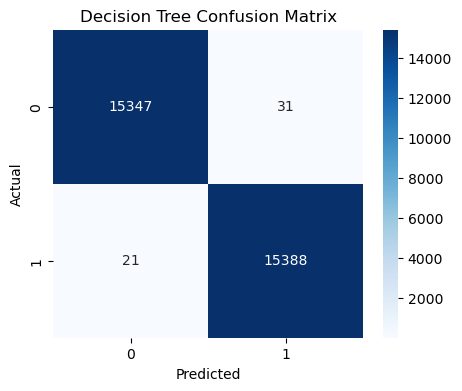

In [31]:
# Decision Tree

dt_model = evaluate_model(
    'Decision Tree',
    DecisionTreeClassifier(random_state=42)
)



Random Forest
Accuracy: 0.9993828564004288
Precision: 0.999545572578551
Recall: 0.9992212343435655
F1 Score: 0.9993833771460098

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     15378
           1       1.00      1.00      1.00     15409

    accuracy                           1.00     30787
   macro avg       1.00      1.00      1.00     30787
weighted avg       1.00      1.00      1.00     30787



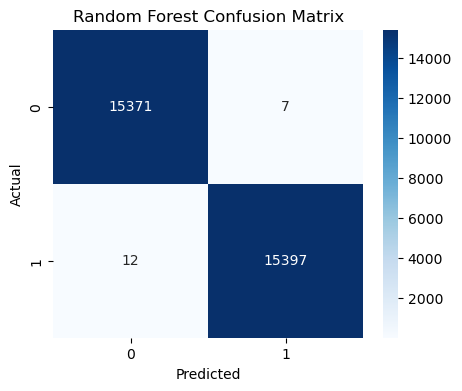

In [32]:
# Random Forest

rf_model = evaluate_model(
    'Random Forest',
    RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
)



KNN
Accuracy: 0.9946081138142723
Precision: 0.9946135375429943
Recall: 0.9946135375429943
F1 Score: 0.9946135375429943

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     15378
           1       0.99      0.99      0.99     15409

    accuracy                           0.99     30787
   macro avg       0.99      0.99      0.99     30787
weighted avg       0.99      0.99      0.99     30787



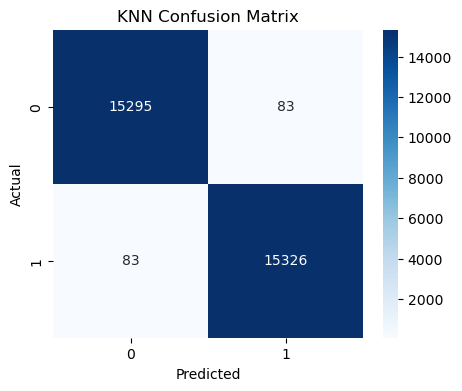

In [33]:
# KNN

knn_model = evaluate_model(
    'KNN',
    KNeighborsClassifier(n_neighbors=5)
)


In [ ]:
# SVM

svm_model = evaluate_model(
    'SVM',
    SVC()
)


In [ ]:
# XGBoost

xgb_model = evaluate_model(
    'XGBoost',
    XGBClassifier(
        eval_metric='logloss',
        use_label_encoder=False
    )
)


# Model Comparison

In [ ]:
results_df = pd.DataFrame(results)

results_df


In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x='Model', y='Accuracy', data=results_df)
plt.xticks(rotation=20)
plt.title('Model Accuracy Comparison')
plt.show()


# Feature Importance

In [ ]:
importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(15)


In [ ]:
plt.figure(figsize=(12,8))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(15)
)

plt.title('Top 15 Important Features')
plt.show()


# PyCaret AutoML Workflow

In [ ]:
!pip install pycaret

In [ ]:
# PyCaret Workflow

from pycaret.classification import *

pycaret_df = pd.concat([X, y], axis=1)

clf = setup(
    data=pycaret_df,
    target='label',
    session_id=42,
    normalize=True,
    feature_selection=True,
    remove_multicollinearity=True,
    verbose=False
)


In [ ]:
# Compare All Models

best_model = compare_models()


In [ ]:
# Create Specific Models

dt = create_model('dt')
rf = create_model('rf')
svm = create_model('svm')
xgb = create_model('xgboost')


In [ ]:
# Evaluate Random Forest

evaluate_model(rf)


In [ ]:
# Tune Random Forest

tuned_rf = tune_model(rf)


In [ ]:
# Save Model

save_model(tuned_rf, 'intrusion_detection_rf')



# Conclusion

Key Findings:

- Random Forest and XGBoost usually achieve highest accuracy.
- Feature scaling and preprocessing significantly improve performance.
- PyCaret simplifies ML workflow and model comparison.
- Intrusion Detection Systems are critical for cybersecurity.

